In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import random
import os
import gc
import time
import matplotlib.pyplot as plt
#from livelossplot.keras import PlotLossesCallback
from tensorflow.keras.callbacks import ReduceLROnPlateau
#from keras.models import load_model
import csv
from itertools import chain

D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\s

### 设置GPU显存按需分配

In [2]:
#如果没有装GPU版本，这部分就不用写，但是如果不用GPU加速计算，使用CPU将会严重限制模型的训练速度
gpus = tf.config.experimental.list_physical_devices('GPU') 
if gpus:
  try:

    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:

    print(e)

1 Physical GPUs, 1 Logical GPUs


In [3]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
cpus = tf.config.experimental.list_physical_devices(device_type='CPU')
print(gpus, cpus)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [4]:
print(tf.__version__)

1.14.0


In [5]:
def reset_seed(seed=42):
    tf.keras.backend.clear_session()
    random.seed(seed)
    np.random.seed(seed)
    tf.set_random_seed(seed)

### 载入数据

In [6]:
data_train=pd.read_csv('F:/TensorFlow/xinjiang/traindata20240724.csv',header=0,encoding='utf_8')
data_train.info()
data_train.className.unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1336 entries, 0 to 1335
Columns: 319 entries, className to Y
dtypes: float64(17), int64(301), object(1)
memory usage: 3.3+ MB


array(['芦苇草甸', '芦苇盐生草甸（含盐生半灌木）', '盐生草荒漠', '木本猪毛菜荒漠',
       '寸草苔草甸（1:100图，薹草、杂类草草甸）', '蒿叶猪毛菜荒漠', '新疆银穗草草原', '戈壁藜荒漠', '麻黄荒漠',
       '合头草荒漠', '短叶假木贼荒漠', '枇杷柴荒漠', '芦苇盐生草甸', '霸王荒漠', '含盐生半灌木的芦苇盐生草甸',
       '膜果麻黄荒漠', '疏叶骆驼刺盐生草甸', '柽柳灌丛', '多枝柽柳荒漠', '含多枝柽柳的芦苇盐生草甸', '花花柴盐生草甸',
       '含多枝柽柳的花花柴盐生草甸', '裸地', '驼绒藜荒漠', '冷蒿荒漠草原', '猪毛菜属荒漠', '芨芨草草原',
       '旱蒿荒漠', '短花针茅荒漠草原', '镰芒针茅矮半灌木荒漠草原', '梭梭荒漠', '沙拐枣属荒漠', '芨芨草草甸',
       '柽柳属荒漠', '紫花针茅草原', '新疆银穗草、穗状寒生羊茅荒漠草原', '小针茅荒漠草原', '紫花针茅、新疆银穗草草原',
       '蒿属荒漠', '锦鸡儿、镰芒针茅荒漠草原', '针茅草原', '盐生假木贼荒漠', '线叶嵩草草甸', '绢蒿属荒漠',
       '沙生针茅荒漠草原', '羊茅、杂类草草甸草原', '昆仑针茅、高山绢蒿荒漠草原', '早熟禾杂类草草甸', '克氏针茅草原',
       '其它薹草草甸', '羊茅草原', '其它嵩草草甸', '高山嵩草高寒草甸', '杂类草高寒草甸', '早熟禾草甸',
       '草原苔草、杂类草草甸草原', '白茎绢蒿荒漠', '人工草地', '短花针茅典型草原', '高山绢蒿荒漠', '鸭茅草甸',
       '早熟禾、羽衣草草甸', '镰芒针茅荒漠草原', '小蓬荒漠', '薹草、珠芽蓼高寒草甸', '新疆薹草草原', '新疆针茅草原',
       '盐生木荒漠', '粗毛锦鸡儿荒漠', '红砂荒漠', '胡杨荒漠', '芦苇草原', '芦苇荒漠', '锦鸡儿荒漠',
       '骆驼刺荒漠'], dtype=object)

In [7]:
pd.set_option('display.max_rows', None)
print(data_train['className'].value_counts())

芦苇草甸                      106
裸地                        100
梭梭荒漠                       61
针茅草原                       44
多枝柽柳荒漠                     44
紫花针茅草原                     44
驼绒藜荒漠                      41
含多枝柽柳的芦苇盐生草甸               38
疏叶骆驼刺盐生草甸                  33
枇杷柴荒漠                      29
芦苇盐生草甸                     27
旱蒿荒漠                       26
盐生假木贼荒漠                    26
芨芨草草原                      24
柽柳属荒漠                      24
线叶嵩草草甸                     22
其它薹草草甸                     21
芦苇荒漠                       21
猪毛菜属荒漠                     20
麻黄荒漠                       20
膜果麻黄荒漠                     19
高山绢蒿荒漠                     19
白茎绢蒿荒漠                     18
戈壁藜荒漠                      18
红砂荒漠                       17
其它嵩草草甸                     17
胡杨荒漠                       17
冷蒿荒漠草原                     17
粗毛锦鸡儿荒漠                    17
沙拐枣属荒漠                     16
合头草荒漠                      16
小蓬荒漠                       14
花花柴盐生草甸                    14
短叶假木贼荒漠   

In [8]:
data_train.head()

,className,num,AET2020,AET2021,AET2101,AET2102,AET2103,AET2104,AET2105,AET2106,...,SR230821b07,SR230829b01,SR230829b02,SR230829b03,SR230829b04,SR230829b05,SR230829b06,SR230829b07,X,Y
0,芦苇草甸,0,39.333333,47.000000,0,32,71,50,66,58,...,1560,1576,2476,921,1406,2463,2369,1910,86.766240,42.038998
1,芦苇盐生草甸（含盐生半灌木）,1,47.083333,36.333333,0,9,15,18,82,114,...,3035,2671,3348,1485,2305,3488,3677,3190,84.183913,41.281745
2,芦苇草甸,0,46.500000,42.000000,0,30,36,22,98,127,...,2714,2272,2848,1371,1929,2958,3098,2817,84.276200,41.521080
3,芦苇草甸,0,18.166667,21.750000,0,1,79,8,48,30,...,2167,2044,2916,1104,1752,2971,2739,2031,86.637723,41.022153
4,芦苇盐生草甸（含盐生半灌木）,1,9.250000,15.166667,0,0,72,8,42,12,...,2333,1626,2597,836,1359,2653,2585,1955,87.885933,40.463570


In [9]:
# 生成该区间的随意唯一索引
index = np.random.permutation(len(data_train))
# 用生成的乱的索引就能将其打乱了
data_all = data_train.iloc[index ,:]

### 类别数量

In [10]:
num_classes = data_train['num'].nunique()
print(num_classes)

75


### 切分数据集（已经提前切分的话不用此部分）

In [11]:
split_index = int(len(data_all)*0.8)
data_train = data_all.iloc[:split_index]

data_test = data_all.iloc[split_index:]
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 268 entries, 865 to 975
Columns: 319 entries, className to Y
dtypes: float64(17), int64(301), object(1)
memory usage: 670.0+ KB


In [12]:
#train_x = data_train.iloc[:,data_train.columns.str.contains("SR")]
#train_x = data_train.iloc[:,~ data_train.columns.str.contains('ClassName|num|SR')]
train_x = data_train.iloc[:,2:]
train_y = data_train.loc[:, ['num']] 

#test_x = data_test.iloc[:,data_train.columns.str.contains("SR")]
#test_x = data_test.iloc[:,~ data_test.columns.str.contains('ClassName|num|SR')]
test_x = data_test.iloc[:,2:]
test_y = data_test.loc[:, ['num']] 
train_x.head(), train_y.head()

(        AET2020     AET2021  AET2101  AET2102  AET2103  AET2104  AET2105  \
 842  234.083333  233.416667        0        0        0        0      277   
 542   39.583333   51.333333        0       30      112       63       78   
 618   67.333333   57.666667        0        0      193       39       24   
 259   49.583333   49.083333        0        0       68       33       22   
 415   90.666667   90.583333        0        0       31      376       46   
 
      AET2106  AET2107  AET2108  ...  SR230821b07  SR230829b01  SR230829b02  \
 842      870      822      613  ...         1767          972         2569   
 542       50       29      101  ...         1605         1140         3168   
 618       29      114       85  ...         3204         1977         2458   
 259       19      177      127  ...         1947         1356         1491   
 415      205       91      162  ...         2839         2283         2705   
 
      SR230829b03  SR230829b04  SR230829b05  SR230829b06  SR

### 顺序编码转独热编码

In [13]:
train_y = tf.keras.utils.to_categorical(train_y)

In [14]:
pd.set_option('display.max_columns', None)
train_y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [15]:
train_y.shape[1]

75

In [16]:
dim_num = train_x.shape[1]
print(dim_num)

317


### 定义损失函数为Focal Loss

In [17]:
def multi_category_focal_loss2(gamma=2., alpha=.25):
    """
    focal loss for multi category of multi label problem
    适用于多分类或多标签问题的focal loss
    alpha控制真值y_true为1/0时的权重
        1的权重为alpha, 0的权重为1-alpha
    当你的模型欠拟合，学习存在困难时，可以尝试适用本函数作为loss
    当模型过于激进(无论何时总是倾向于预测出1),尝试将alpha调小
    当模型过于惰性(无论何时总是倾向于预测出0,或是某一个固定的常数,说明没有学到有效特征)
        尝试将alpha调大,鼓励模型进行预测出1。
    Usage:
     model.compile(loss=[multi_category_focal_loss2(alpha=0.25, gamma=2)], metrics=["accuracy"], optimizer='adam')
    """
    epsilon = 1.e-7
    gamma = float(gamma)
    alpha = tf.constant(alpha, dtype=tf.float32)

    def multi_category_focal_loss2_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    
        alpha_t = y_true*alpha + (tf.ones_like(y_true)-y_true)*(1-alpha)
        y_t = tf.multiply(y_true, y_pred) + tf.multiply(1-y_true, 1-y_pred)
        y_t = tf.clip_by_value(y_t, epsilon, 1. - epsilon)#这句是后加的
        ce = -tf.math.log(y_t)
        weight = tf.math.pow(tf.subtract(1., y_t), gamma)
        fl = tf.multiply(tf.multiply(weight, ce), alpha_t)
        loss = tf.reduce_mean(fl)
        return loss
    return multi_category_focal_loss2_fixed

### 模型构建

In [18]:
reset_seed()
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(4096,input_dim=dim_num))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(2048,activation='relu',kernel_regularizer=tf.contrib.layers.l2_regularizer(0.003)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(1024,activation='relu',kernel_regularizer=tf.contrib.layers.l2_regularizer(0.003)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(512,activation='relu',kernel_regularizer=tf.contrib.layers.l2_regularizer(0.003)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(256,activation='relu',kernel_regularizer=tf.contrib.layers.l2_regularizer(0.003)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(128,activation='relu',kernel_regularizer=tf.contrib.layers.l2_regularizer(0.003)))
model.add(tf.keras.layers.BatchNormalization())
#model.add(tf.keras.layers.Dense(64,activation='relu'))
#model.add(tf.keras.layers.BatchNormalization())
#model.add(tf.keras.layers.Dense(32,activation='relu'))#注：如果后面再加16，8，16，32这样的全连结层，精度反而会变低
model.add(tf.keras.layers.Dropout(rate=0.3))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))
# 让学习率自动变化
reduce_lr = ReduceLROnPlateau(monitor='loss',factor=0.01, patience=20, mode='auto')
model.compile(loss=[multi_category_focal_loss2(alpha=0.25, gamma=2)], metrics=['acc'], optimizer='adam')#adam优化
#顺序编码用loss='sparse_categorical_crossentropy'
#独热编码用loss='categorical_crossentropy'
model.summary()


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 4096)              1302528   
_________________________________________________________________
batch_normalization (BatchNo (None, 4096)              16384     
_________________________________________________________________
dense_1 (Dense)              (None, 2048)              8390656   
___________________________________

### 开始训练

In [19]:
e = 400
start = time.perf_counter()#time.process_time()测的时间偏长
history = model.fit(train_x,train_y, epochs=e,batch_size=64,verbose=1,callbacks=[reduce_lr])#batch_size=16,validation_data=(validation_x,validation_y)
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Epoch 1/400
1068/1068 [==============================] - 1s 851us/sample - loss: 4.7582 - acc: 0.0908
Epoch 2/400
1068/1068 [==============================] - 0s 138us/sample - loss: 1.1849 - acc: 0.1199
Epoch 3/400
1068/1068 [==============================] - 0s 130us/sample - loss: 0.3854 - acc: 0.1451
Epoch 4/400
1068/1068 [==============================] - 0s 132us/sample - loss: 0.1689 - acc: 0.1404
Epoch 5/400
1068/1068 [==============================] - 0s 136us/sample - loss: 0.0862 - acc: 0.1657
Epoch 6/400
1068/1068 [==============================] - 0s 132us/sample - loss: 0.0506 - acc: 0.1779
Epoch 7/400
1068/1068 [==============================] - 0s 132us/sample - loss: 0.0343 - acc: 0.1620
Epoch 8/400
1068/1068 [==============================] - 0s 135us/sample - loss: 0.0255 - acc: 0.1582
Epoch 9/400
1068/1068 [==============================] - 0s 133us/sample - loss: 0.0213 - 

1068/1068 [==============================] - 0s 133us/sample - loss: 0.0087 - acc: 0.2940
Epoch 78/400
1068/1068 [==============================] - 0s 130us/sample - loss: 0.0088 - acc: 0.2725
Epoch 79/400
1068/1068 [==============================] - 0s 132us/sample - loss: 0.0086 - acc: 0.2978
Epoch 80/400
1068/1068 [==============================] - 0s 130us/sample - loss: 0.0084 - acc: 0.2893
Epoch 81/400
1068/1068 [==============================] - 0s 133us/sample - loss: 0.0084 - acc: 0.2968
Epoch 82/400
1068/1068 [==============================] - 0s 130us/sample - loss: 0.0085 - acc: 0.3081
Epoch 83/400
1068/1068 [==============================] - 0s 131us/sample - loss: 0.0083 - acc: 0.3034
Epoch 84/400
1068/1068 [==============================] - 0s 130us/sample - loss: 0.0082 - acc: 0.2978
Epoch 85/400
1068/1068 [==============================] - 0s 130us/sample - loss: 0.0082 - acc: 0.2978
Epoch 86/400
1068/1068 [==============================] - 0s 132us/sample - loss: 0.00

1068/1068 [==============================] - 0s 129us/sample - loss: 0.0053 - acc: 0.5843
Epoch 157/400
1068/1068 [==============================] - 0s 131us/sample - loss: 0.0055 - acc: 0.5590
Epoch 158/400
1068/1068 [==============================] - 0s 132us/sample - loss: 0.0055 - acc: 0.5637
Epoch 159/400
1068/1068 [==============================] - 0s 130us/sample - loss: 0.0051 - acc: 0.6039
Epoch 160/400
1068/1068 [==============================] - 0s 130us/sample - loss: 0.0051 - acc: 0.5946
Epoch 161/400
1068/1068 [==============================] - 0s 134us/sample - loss: 0.0052 - acc: 0.5964
Epoch 162/400
1068/1068 [==============================] - 0s 129us/sample - loss: 0.0052 - acc: 0.5936
Epoch 163/400
1068/1068 [==============================] - 0s 125us/sample - loss: 0.0049 - acc: 0.6395
Epoch 164/400
1068/1068 [==============================] - 0s 132us/sample - loss: 0.0050 - acc: 0.6264
Epoch 165/400
1068/1068 [==============================] - 0s 130us/sample - l

1068/1068 [==============================] - 0s 132us/sample - loss: 0.0030 - acc: 0.8773
Epoch 235/400
1068/1068 [==============================] - 0s 128us/sample - loss: 0.0031 - acc: 0.8670
Epoch 236/400
1068/1068 [==============================] - 0s 130us/sample - loss: 0.0033 - acc: 0.8324
Epoch 237/400
1068/1068 [==============================] - 0s 129us/sample - loss: 0.0029 - acc: 0.8867
Epoch 238/400
1068/1068 [==============================] - 0s 130us/sample - loss: 0.0030 - acc: 0.8764
Epoch 239/400
1068/1068 [==============================] - 0s 130us/sample - loss: 0.0029 - acc: 0.8830
Epoch 240/400
1068/1068 [==============================] - 0s 132us/sample - loss: 0.0029 - acc: 0.8998
Epoch 241/400
1068/1068 [==============================] - 0s 129us/sample - loss: 0.0028 - acc: 0.9036
Epoch 242/400
1068/1068 [==============================] - 0s 130us/sample - loss: 0.0029 - acc: 0.8951
Epoch 243/400
1068/1068 [==============================] - 0s 133us/sample - l

1068/1068 [==============================] - 0s 136us/sample - loss: 0.0019 - acc: 0.9747
Epoch 313/400
1068/1068 [==============================] - 0s 128us/sample - loss: 0.0019 - acc: 0.9728
Epoch 314/400
1068/1068 [==============================] - 0s 123us/sample - loss: 0.0019 - acc: 0.9700
Epoch 315/400
1068/1068 [==============================] - 0s 136us/sample - loss: 0.0019 - acc: 0.9775
Epoch 316/400
1068/1068 [==============================] - 0s 131us/sample - loss: 0.0018 - acc: 0.9831
Epoch 317/400
1068/1068 [==============================] - 0s 121us/sample - loss: 0.0018 - acc: 0.9813
Epoch 318/400
1068/1068 [==============================] - 0s 136us/sample - loss: 0.0018 - acc: 0.9822
Epoch 319/400
1068/1068 [==============================] - 0s 128us/sample - loss: 0.0018 - acc: 0.9831
Epoch 320/400
1068/1068 [==============================] - 0s 131us/sample - loss: 0.0018 - acc: 0.9803
Epoch 321/400
1068/1068 [==============================] - 0s 131us/sample - l

1068/1068 [==============================] - 0s 130us/sample - loss: 0.0017 - acc: 0.9906
Epoch 391/400
1068/1068 [==============================] - 0s 130us/sample - loss: 0.0017 - acc: 0.9869
Epoch 392/400
1068/1068 [==============================] - 0s 128us/sample - loss: 0.0018 - acc: 0.9813
Epoch 393/400
1068/1068 [==============================] - 0s 131us/sample - loss: 0.0017 - acc: 0.9878
Epoch 394/400
1068/1068 [==============================] - 0s 131us/sample - loss: 0.0018 - acc: 0.9878
Epoch 395/400
1068/1068 [==============================] - 0s 131us/sample - loss: 0.0018 - acc: 0.9850
Epoch 396/400
1068/1068 [==============================] - 0s 128us/sample - loss: 0.0017 - acc: 0.9888
Epoch 397/400
1068/1068 [==============================] - 0s 130us/sample - loss: 0.0017 - acc: 0.9869
Epoch 398/400
1068/1068 [==============================] - 0s 131us/sample - loss: 0.0017 - acc: 0.9803
Epoch 399/400
1068/1068 [==============================] - 0s 131us/sample - l

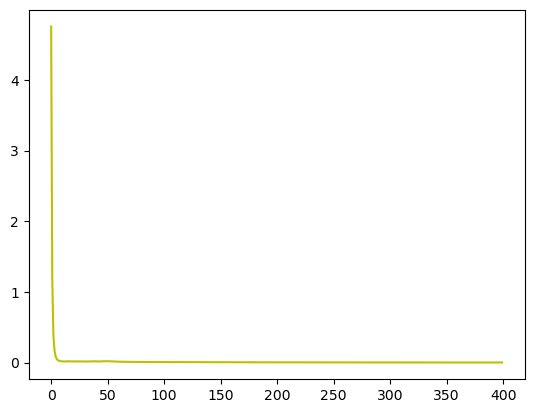

In [20]:
plt.plot(range(e),history.history.get('loss'),color =  'y')

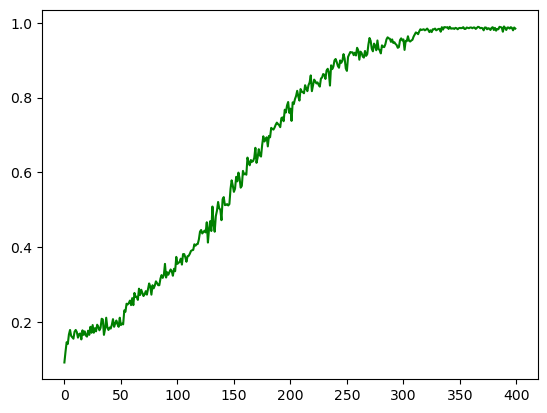

In [21]:
plt.plot(range(e),history.history.get('acc'),color =  'g')

### 计算准确率

In [22]:
test_r = pd.DataFrame(model.predict_classes(test_x,verbose=1))
test_r = test_r.values
# Accuracy
acc = accuracy_score(test_y, test_r)

# Precision, Recall, F1 (macro平均适用于多分类)
precision = precision_score(test_y, test_r, average='macro')
recall = recall_score(test_y, test_r, average='macro')
f1 = f1_score(test_y, test_r, average='macro')

# Confusion Matrix
cm = confusion_matrix(test_y, test_r)

print("Accuracy:", acc)
print("Precision (macro):", precision)
print("Recall (macro):", recall)
print("F1 Score (macro):", f1)
print("Confusion Matrix:\n", cm)

268/268 [==============================] - 0s 328us/sample
Accuracy: 0.31716417910447764
Precision (macro): 0.2201078242744909
Recall (macro): 0.2072195165945166
F1 Score (macro): 0.1950764690341574
Confusion Matrix:
 [[12  0  0 ...  1  0  0]
 [ 1  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 ...
 [ 2  0  0 ...  1  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]]


D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### 各类别准确率

In [23]:
# 创建 num 到 className 的映射（取 data_train 中唯一的映射关系）
num_to_name = data_train.drop_duplicates(subset='num').set_index('num')['className'].to_dict()

# 每类准确率 = 对角线元素 / 该类总数（行和）
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

# 输出每个类别的名称和准确率
print("每个类别的准确率：")
for i, acc in zip(sorted(num_to_name.keys()), per_class_accuracy):
    name = num_to_name[i]
    print(f"{name}: {acc:.2%}")

每个类别的准确率：
芦苇草甸: 54.55%
芦苇盐生草甸（含盐生半灌木）: 0.00%
盐生草荒漠: 0.00%
木本猪毛菜荒漠: 0.00%
寸草苔草甸（1:100图，薹草、杂类草草甸）: 100.00%
蒿叶猪毛菜荒漠: 0.00%
新疆银穗草草原: 33.33%
戈壁藜荒漠: 100.00%
麻黄荒漠: 40.00%
合头草荒漠: 25.00%
短叶假木贼荒漠: 50.00%
枇杷柴荒漠: 14.29%
芦苇盐生草甸: 0.00%
霸王荒漠: 0.00%
含盐生半灌木的芦苇盐生草甸: 0.00%
膜果麻黄荒漠: 25.00%
疏叶骆驼刺盐生草甸: 33.33%
柽柳灌丛: nan%
多枝柽柳荒漠: 16.67%
含多枝柽柳的芦苇盐生草甸: 44.44%
花花柴盐生草甸: 50.00%
含多枝柽柳的花花柴盐生草甸: nan%
裸地: 75.00%
驼绒藜荒漠: 36.36%
冷蒿荒漠草原: 57.14%
猪毛菜属荒漠: 50.00%
芨芨草草原: 22.22%
旱蒿荒漠: 20.00%
短花针茅荒漠草原: 0.00%
镰芒针茅矮半灌木荒漠草原: 0.00%
梭梭荒漠: 25.00%
沙拐枣属荒漠: 0.00%
芨芨草草甸: 0.00%
柽柳属荒漠: 0.00%
紫花针茅草原: 57.14%
新疆银穗草、穗状寒生羊茅荒漠草原: 100.00%
小针茅荒漠草原: 0.00%
紫花针茅、新疆银穗草草原: 0.00%
蒿属荒漠: nan%
锦鸡儿、镰芒针茅荒漠草原: nan%
针茅草原: 16.67%
盐生假木贼荒漠: 33.33%
线叶嵩草草甸: 25.00%
绢蒿属荒漠: nan%
沙生针茅荒漠草原: 0.00%
羊茅、杂类草草甸草原: 0.00%
昆仑针茅、高山绢蒿荒漠草原: 66.67%
早熟禾杂类草草甸: 0.00%
克氏针茅草原: 25.00%
其它薹草草甸: 0.00%
羊茅草原: 0.00%
其它嵩草草甸: 0.00%
高山嵩草高寒草甸: 0.00%
杂类草高寒草甸: 0.00%
早熟禾草甸: 0.00%
草原苔草、杂类草草甸草原: 33.33%
白茎绢蒿荒漠: 50.00%
人工草地: 0.00%
短花针茅典型草原: 62.50%
高山绢蒿荒漠: 0.00%
鸭茅草甸: nan%
早熟禾、羽衣草草甸: 50.00%
镰芒针茅荒漠草原: 0.00%
小

D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in true_divide
  """
